In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

START_DATE = '1995-01-01'
END_DATE   = '2007-12-31'

print('Libraries loaded.')

Libraries loaded.


# Check Data Quality

## Stock Market Data

In [2]:
stock_df = pd.read_csv('sp500_adjclose_1995_2007_REDEFINED_500cols.csv', index_col='Date', parse_dates=True)

In [3]:
print(f'Adj Close  shape: {stock_df.shape}')
print(f'Date range: {stock_df.index.min().date()} -> {stock_df.index.max().date()}')

Adj Close  shape: (3272, 500)
Date range: 1995-01-03 -> 2007-12-28


In [4]:
null_count  = stock_df.isna().sum()
null_pct    = stock_df.isna().mean() * 100
zero_count  = (stock_df == 0).sum()
neg_count   = (stock_df < 0).sum()

print(f'\nTotal trading days: {len(stock_df)}')
print(f'Stocks with >50% missing: {(null_pct > 50).sum()}')
print(f'Stocks with >20% missing: {(null_pct > 20).sum()}')
print(f'Stocks with >5% missing: {(null_pct > 5).sum()}')
print(f'Stocks fully empty (100% null): {(null_pct == 100).sum()}')
print(f'Any negative prices: {(neg_count > 0).sum()} tickers')
print(f'Any zero prices: {(zero_count > 0).sum()} tickers')

stock_qc = pd.DataFrame({
    'null_days':  null_count,
    'null_pct':   null_pct.round(1),
    'zero_price': zero_count,
    'neg_price':  neg_count,
}).sort_values('null_pct', ascending=False)

print(stock_qc.head(10))


Total trading days: 3272
Stocks with >50% missing: 49
Stocks with >20% missing: 93
Stocks with >5% missing: 124
Stocks fully empty (100% null): 0
Any negative prices: 0 tickers
Any zero prices: 0 tickers
      null_days  null_pct  zero_price  neg_price
MSCI       3242      99.1           0          0
ULTA       3227      98.6           0          0
LULU       3164      96.7           0          0
BX         3140      96.0           0          0
TEL        3134      95.8           0          0
PODD       3113      95.1           0          0
DAL        3105      94.9           0          0
IBKR       3106      94.9           0          0
TMUS       3095      94.6           0          0
SMCI       3081      94.2           0          0


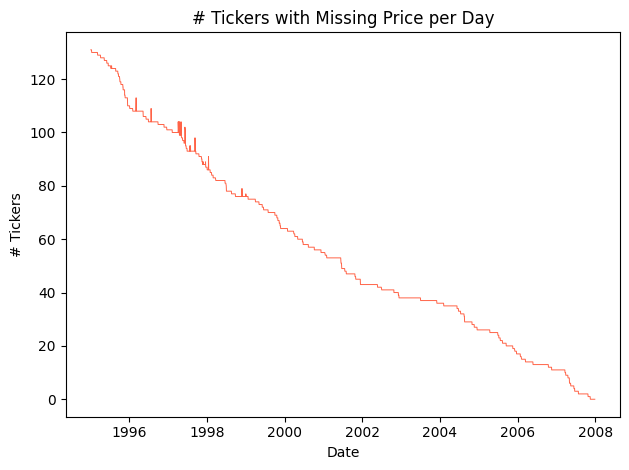

In [5]:
# Missing theo ngày (bao nhiêu ticker null mỗi ngày)
missing_per_day = stock_df.isna().sum(axis=1)

plt.plot(missing_per_day.index, missing_per_day.values, linewidth=0.7, color='tomato')
plt.title('# Tickers with Missing Price per Day')
plt.xlabel('Date')
plt.ylabel('# Tickers')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## ETFs Data

In [6]:
etf_df = pd.read_csv('sector_etfs_adjclose.csv', index_col='Date', parse_dates=True)
print(f'ETF shape: {etf_df.shape}')
print(f'Date range: {etf_df.index.min().date()} -> {etf_df.index.max().date()}')

ETF shape: (2268, 15)
Date range: 1998-12-22 -> 2007-12-28


In [7]:
etf_df.head()

,FDN,IYR,IYT,KRE,OIH,SMH,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,XRT
Date,,,,,,,,,,,,,,,
1998-12-22,NaN,NaN,NaN,NaN,NaN,NaN,5.774109,11.220837,14.472656,11.938131,14.064749,5.873080,16.858889,9.398277,NaN
1998-12-23,NaN,NaN,NaN,NaN,NaN,NaN,5.894323,11.386288,14.725203,12.223345,14.404764,5.848470,17.237738,9.438636,NaN
1998-12-24,NaN,NaN,NaN,NaN,NaN,NaN,5.863298,11.461496,14.919463,12.176774,14.379879,5.956147,17.342987,9.611613,NaN
1998-12-28,NaN,NaN,NaN,NaN,NaN,NaN,5.832281,11.311090,14.997158,12.211702,14.296953,5.925382,17.090410,9.525125,NaN
1998-12-29,NaN,NaN,NaN,NaN,NaN,NaN,5.890444,11.431416,15.210853,12.246622,14.612086,6.023829,17.469265,9.732698,NaN


In [8]:
etf_summary = []

for etf in etf_df.columns:
    etf_summary.append({
        'ticker': etf,
        'rows': len(etf_df[etf].dropna()),
        'start': etf_df[etf].first_valid_index(),
        'end': etf_df[etf].last_valid_index(),
        'missing': etf_df[etf].isna().sum(),
        'pct_missing': etf_df[etf].isna().mean() * 100,
        'negative': (etf_df[etf] < 0).sum(),
        'duplicates': etf_df[etf].index.duplicated().sum()
    })

etf_summary_df = pd.DataFrame(etf_summary)
etf_summary_df

,ticker,rows,start,end,missing,pct_missing,negative,duplicates
0,FDN,382,2006-06-23,2007-12-28,1886,83.156966,0,0
1,IYR,1893,2000-06-19,2007-12-28,375,16.534392,0,0
2,IYT,1005,2004-01-02,2007-12-28,1263,55.687831,0,0
3,KRE,383,2006-06-22,2007-12-28,1885,83.112875,0,0
4,OIH,1720,2001-02-26,2007-12-28,548,24.162257,0,0
5,SMH,1903,2000-06-05,2007-12-28,365,16.093474,0,0
6,XLE,2268,1998-12-22,2007-12-28,0,0.000000,0,0
7,XLF,2268,1998-12-22,2007-12-28,0,0.000000,0,0
8,XLI,2268,1998-12-22,2007-12-28,0,0.000000,0,0
9,XLK,2268,1998-12-22,2007-12-28,0,0.000000,0,0


## Market Cap

In [9]:
mktcap_df = pd.read_csv('market_cap_daily.csv', index_col='Date', parse_dates=True)

In [10]:
print(f'Shape: {mktcap_df.shape}')
print(f'Date range: {mktcap_df.index.min().date()} -> {mktcap_df.index.max().date()}')

null_pct_mc = mktcap_df.isna().mean() * 100
print(f'\nTickers with full market cap data (0% null): {(null_pct_mc == 0).sum()}')
print(f'Tickers completely missing: {(null_pct_mc == 100).sum()}')
print(f'Tickers with >50% missing: {(null_pct_mc > 50).sum()}')
print(f'Tickers with >20% missing: {(null_pct_mc > 20).sum()}')
print(f'Tickers with >5% missing: {(null_pct_mc > 5).sum()}')
print(f'\nTop 10 by missing%:')
print(null_pct_mc.sort_values(ascending=False).head(10).to_string())

# Negative market cap (không hợp lệ)
neg_mc = (mktcap_df < 0).sum()
print(f'\nTickers with any negative market cap: {(neg_mc > 0).sum()}')
if (neg_mc > 0).sum():
    print(neg_mc[neg_mc > 0])

Shape: (3271, 500)
Date range: 1995-01-04 -> 2007-12-28

Tickers with full market cap data (0% null): 288
Tickers completely missing: 88
Tickers with >50% missing: 137
Tickers with >20% missing: 181
Tickers with >5% missing: 204

Top 10 by missing%:
XYL     100.0
VST     100.0
V       100.0
VICI    100.0
VRSK    100.0
VLTO    100.0
AWK     100.0
ABBV    100.0
AMCR    100.0
UBER    100.0

Tickers with any negative market cap: 0


## Mapping Ticker

In [11]:
# Load sector classification từ Wikipedia
import requests
from io import StringIO

url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {"User-Agent": "Mozilla/5.0"}

response = requests.get(url, headers=headers)
sp500 = pd.read_html(StringIO(response.text))[0]

df_sector = sp500[["Symbol", "GICS Sector", "GICS Sub-Industry"]].copy()
df_sector.columns = ["Ticker", "Sector", "SubIndustry"]
df_sector["Ticker"] = df_sector["Ticker"].str.replace(".", "-", regex=False)

# Map to 15 sector classification
def map_to_15_sector(row):
    sector = row["Sector"]
    sub = row["SubIndustry"]
    
    if sector == "Energy":
        return "Oil Exploration" if "Exploration" in sub else "Energy"
    if sector == "Materials":
        return "Industrial"
    if sector == "Industrials":
        return "Transportation" if "Transportation" in sub else "Industrial"
    if sector == "Utilities":
        return "Utility"
    if sector == "Financials":
        return "Regional Banks" if "Regional Banks" in sub else "Financial"
    if sector == "Information Technology":
        return "Semiconductors" if "Semiconductor" in sub else "Technology"
    if sector == "Communication Services":
        return "Internet"
    if sector == "Consumer Discretionary":
        return "Retail" if "Retail" in sub else "Consumer discretionary"
    if sector == "Consumer Staples":
        return "Consumer Staples"
    if sector == "Health Care":
        return "Healthcare"
    if sector == "Real Estate":
        return "Real Estate"
    return "Other"

df_sector["Sector_Classification"] = df_sector.apply(map_to_15_sector, axis=1)

# Keep only tickers that exist in prices_clean1
df_sector = df_sector[df_sector["Ticker"].isin(stock_df.columns)].copy()

print(f"Number of stocks per sector:")
print(df_sector["Sector_Classification"].value_counts())


Number of stocks per sector:
Sector_Classification
Industrial                77
Financial                 59
Healthcare                52
Technology                35
Consumer Staples          30
Real Estate               29
Utility                   28
Consumer discretionary    28
Semiconductors            16
Internet                  16
Retail                    12
Transportation             9
Oil Exploration            8
Energy                     8
Regional Banks             5
Name: count, dtype: int64


In [12]:
df_sector.head()

,Ticker,Sector,SubIndustry,Sector_Classification
0,MMM,Industrials,Industrial Conglomerates,Industrial
1,AOS,Industrials,Building Products,Industrial
2,ABT,Health Care,Health Care Equipment,Healthcare
4,ACN,Information Technology,IT Consulting & Other Services,Technology
5,ADBE,Information Technology,Application Software,Technology


In [13]:
sector_map = {
    "Internet": "HHH",
    "Real Estate": "IYR",
    "Transportation": "IYT",
    "Oil Exploration": "OIH",
    "Regional Banks": "RKH",
    "Retail": "RTH",
    "Semiconductors": "SMH",
    "Utility": "UTH",
    "Energy": "XLE",
    "Financial": "XLF",
    "Industrial": "XLI",
    "Technology": "XLK",
    "Consumer Staples": "XLP",
    "Healthcare": "XLV",
    "Consumer discretionary": "XLY"
}

> mapping sector\_classification in df\_sector by sector\_map and extract to csv file

In [14]:
# Map Sector_Classification to ETF tickers using sector_map, add as a new column, and export to CSV


# Create mapped column
df_sector['Sector_ETF'] = df_sector['Sector_Classification'].map(sector_map)

# Report any unmapped sectors (if any)
unmapped = df_sector[df_sector['Sector_ETF'].isna()]['Sector_Classification'].value_counts()
if len(unmapped) > 0:
    print('Unmapped sector classifications found:')
    print(unmapped.to_string())

# Save to CSV
output_path = 'sector_mapping.csv'
df_sector[['Ticker', 'Sector_Classification', 'Sector_ETF']].to_csv(output_path, index=False)

# Show a preview of the result
df_sector[['Ticker', 'Sector_Classification', 'Sector_ETF']]

,Ticker,Sector_Classification,Sector_ETF
0,MMM,Industrial,XLI
1,AOS,Industrial,XLI
2,ABT,Healthcare,XLV
4,ACN,Technology,XLK
5,ADBE,Technology,XLK
...,...,...,...
493,WMB,Energy,XLE
494,WTW,Financial,XLF
496,WYNN,Consumer discretionary,XLY
497,XEL,Utility,UTH


In [15]:
stock_map_etf = pd.read_csv('sector_mapping.csv')
stock_map_etf.head()

,Ticker,Sector_Classification,Sector_ETF
0,MMM,Industrial,XLI
1,AOS,Industrial,XLI
2,ABT,Healthcare,XLV
3,ACN,Technology,XLK
4,ADBE,Technology,XLK


# Handle missing value

In [16]:
# Xóa các cột có missing value > 5%
stock_cleaned = stock_df.loc[:, null_pct <= 5]

print("Original columns:", stock_df.shape[1])
print("Remaining columns:", stock_cleaned.shape[1])
print("Dropped columns:", stock_df.shape[1] - stock_cleaned.shape[1])

Original columns: 500
Remaining columns: 376
Dropped columns: 124


In [17]:
print("Total missing before:", stock_df.isna().sum().sum())
print("Total missing after :", stock_cleaned.isna().sum().sum())

Total missing before: 185619
Total missing after : 610


In [18]:
missing_per_col = stock_cleaned.isna().sum()
print(missing_per_col[missing_per_col > 0].sort_values(ascending=False))

FCX     130
WAB     115
RMD     105
DRI      88
COR      64
DLTR     44
ANDV     14
TWX      12
SVU      10
BMS      10
ESRX      9
EME       5
MOLX      3
CIN       1
dtype: int64


In [19]:
cols_to_drop = ["FCX", "WAB", "RMD", "DRI", "COR", "DLTR", "EME"]

stock_cleaned = stock_cleaned.drop(columns=cols_to_drop, errors='ignore')

In [20]:
print("Total missing before:", stock_df.isna().sum().sum())
print("Total missing after :", stock_cleaned.isna().sum().sum())

Total missing before: 185619
Total missing after : 59


In [21]:
# 4️⃣ Compute returns
returns_filtered = stock_cleaned.pct_change().dropna()
etf_returns = etf_df.pct_change()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_5872\2863307449.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_filtered = stock_cleaned.pct_change().dropna()


# Filter stocks with market\_cap \> $1B

In [22]:
cap_threshold = 1e9

# Align universe
common_cols = stock_cleaned.columns.intersection(mktcap_df.columns)

prices_aligned = stock_cleaned[common_cols]
returns_aligned = returns_filtered[common_cols]
market_cap_aligned = mktcap_df[common_cols]

cap_mask = market_cap_aligned.shift(1) > cap_threshold
returns_filtered = returns_aligned.where(cap_mask)

print("Initial stocks:", prices_aligned.shape[1])
print("Dynamic filtering applied (no look-ahead).")
print(returns_filtered.shape[1])

Initial stocks: 288
Dynamic filtering applied (no look-ahead).
288


In [23]:
returns_filtered.head()

,MMM,AOS,ABT,ADBE,AMD,AES,AFL,APD,ALB,LNT,...,WM,WEC,WFC,WELL,WST,WDC,WY,WSM,WMB,XEL
Date,,,,,,,,,,,,,,,,,,,,,
1995-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1995-01-05,0.000000,NaN,-0.007633,0.039130,-0.004878,0.000000,NaN,0.002770,NaN,NaN,...,0.000000,0.000000,0.010929,0.024096,NaN,-0.007353,0.019738,NaN,0.014493,0.002817
1995-01-06,-0.004684,NaN,-0.015384,0.020921,0.093137,0.025974,NaN,0.000000,NaN,NaN,...,-0.011111,0.004784,0.005405,0.023530,NaN,0.014815,0.019355,NaN,-0.023809,-0.002809
1995-01-09,0.000000,NaN,-0.001886,0.012295,0.035874,-0.025316,NaN,-0.005525,NaN,NaN,...,-0.011236,-0.009524,-0.016129,0.011494,NaN,0.072992,0.025316,NaN,-0.004878,0.002817
1995-01-10,0.000000,NaN,-0.015748,0.018219,0.008658,-0.012987,NaN,0.005556,NaN,NaN,...,-0.011363,0.004808,0.000000,-0.005683,NaN,0.006803,-0.006173,NaN,-0.024510,0.002809


# Synthetic ETFs

In [24]:
def build_synthetic_etfs(df_sector, returns_filtered, market_cap_aligned):

    sector_returns = {}

    for sector in df_sector["Sector_Classification"].unique():

        tickers = df_sector.loc[
            df_sector["Sector_Classification"] == sector,
            "Ticker"
        ]

        tickers = [t for t in tickers if t in returns_filtered.columns]
        if len(tickers) == 0:
            continue

        mc = market_cap_aligned[tickers].shift(1)
        mc = mc.where(mc > 1e9)

        weights = mc.div(mc.sum(axis=1), axis=0)

        sec_ret = (weights * returns_filtered[tickers]).sum(axis=1)
        sector_returns[sector] = sec_ret

    return pd.DataFrame(sector_returns)

In [25]:
sector_returns = build_synthetic_etfs(
    df_sector=df_sector,
    returns_filtered=returns_filtered,
    market_cap_aligned=market_cap_aligned
)

print("Synthetic ETFs shape:", sector_returns.shape)
print("Sectors:", list(sector_returns.columns))
print(sector_returns.head())

Synthetic ETFs shape: (3271, 15)
Sectors: ['Industrial', 'Healthcare', 'Technology', 'Semiconductors', 'Utility', 'Financial', 'Real Estate', 'Internet', 'Consumer Staples', 'Retail', 'Oil Exploration', 'Energy', 'Consumer discretionary', 'Transportation', 'Regional Banks']
            Industrial  Healthcare  Technology  Semiconductors   Utility  \
Date                                                                       
1995-01-04    0.000000    0.000000    0.000000        0.000000  0.000000   
1995-01-05    0.003283    0.003102   -0.007140       -0.003753 -0.002285   
1995-01-06    0.003887   -0.001480    0.016883        0.040150  0.001784   
1995-01-09    0.001393   -0.006626    0.013058        0.017787 -0.001889   
1995-01-10    0.004473    0.003049    0.020191        0.020745  0.002490   

            Financial  Real Estate  Internet  Consumer Staples    Retail  \
Date                                                                       
1995-01-04   0.000000     0.000000  0.00

In [26]:
sector_returns = sector_returns.rename(columns=sector_map)

print(sector_returns.columns)

Index(['XLI', 'XLV', 'XLK', 'SMH', 'UTH', 'XLF', 'IYR', 'HHH', 'XLP', 'RTH',
       'OIH', 'XLE', 'XLY', 'IYT', 'RKH'],
      dtype='object')


### SPY returns

In [27]:
spy_returns = pd.read_csv('spy_returns_1996_2007.csv')
spy_returns = spy_returns.set_index('Date')
spy_returns.index = pd.to_datetime(spy_returns.index)

Common ETFs: ['XLI', 'XLV', 'XLK', 'SMH', 'XLF', 'IYR', 'XLP', 'OIH', 'XLE', 'XLY', 'IYT']


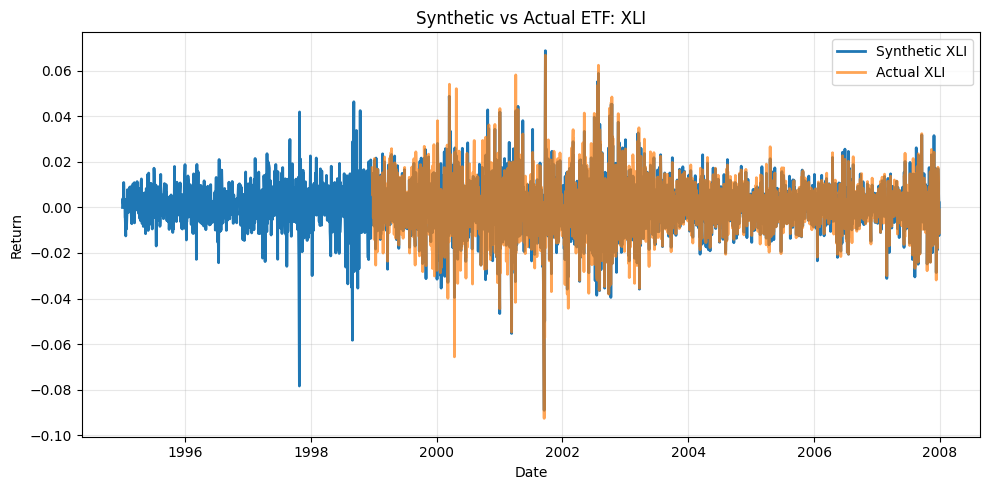

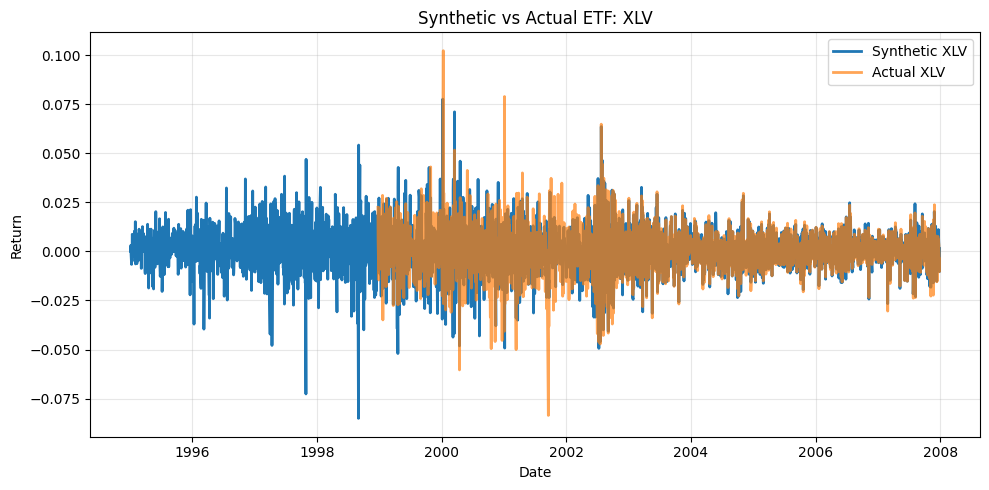

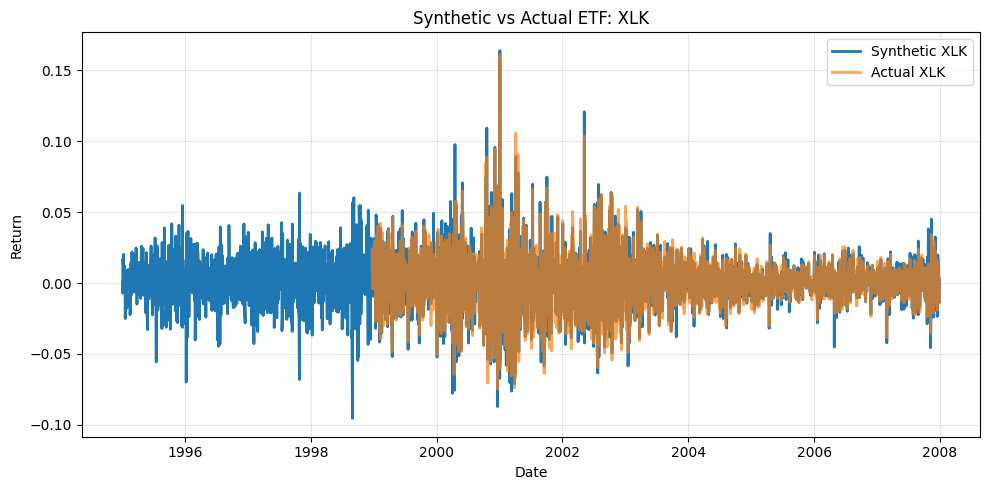

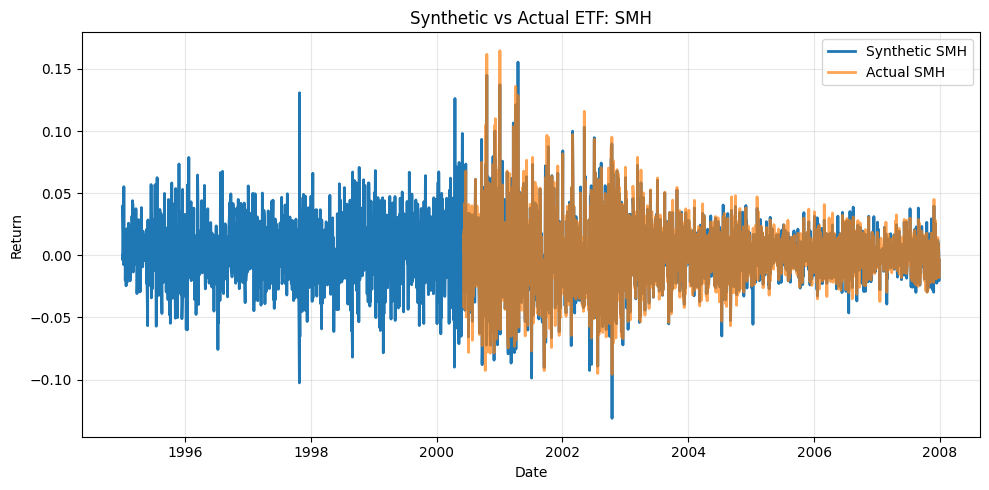

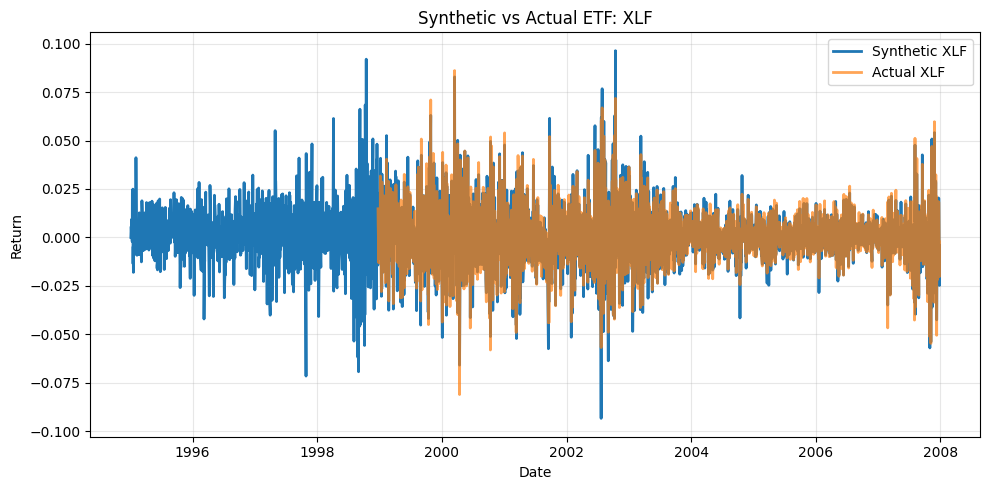

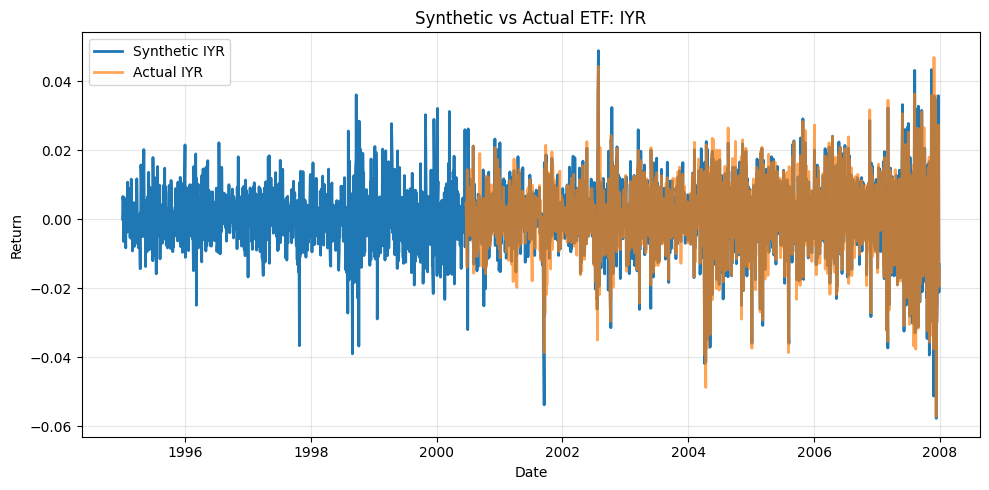

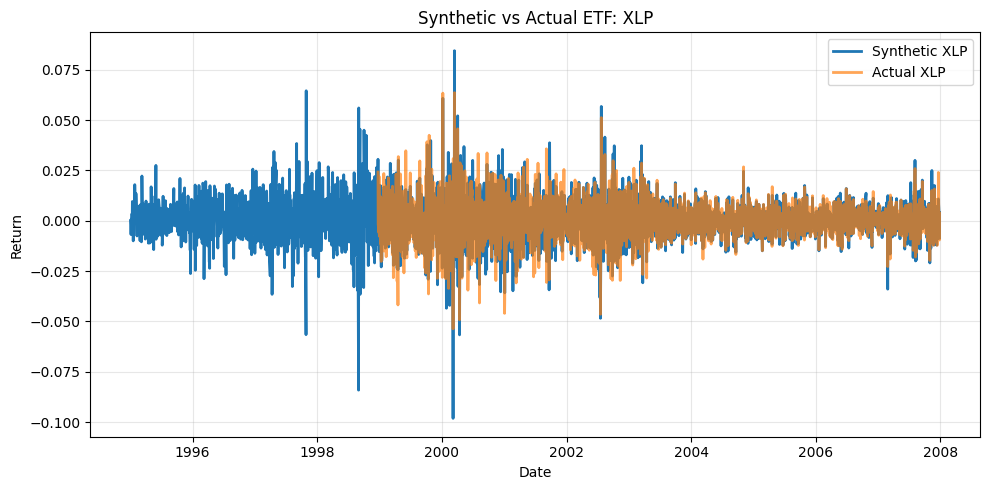

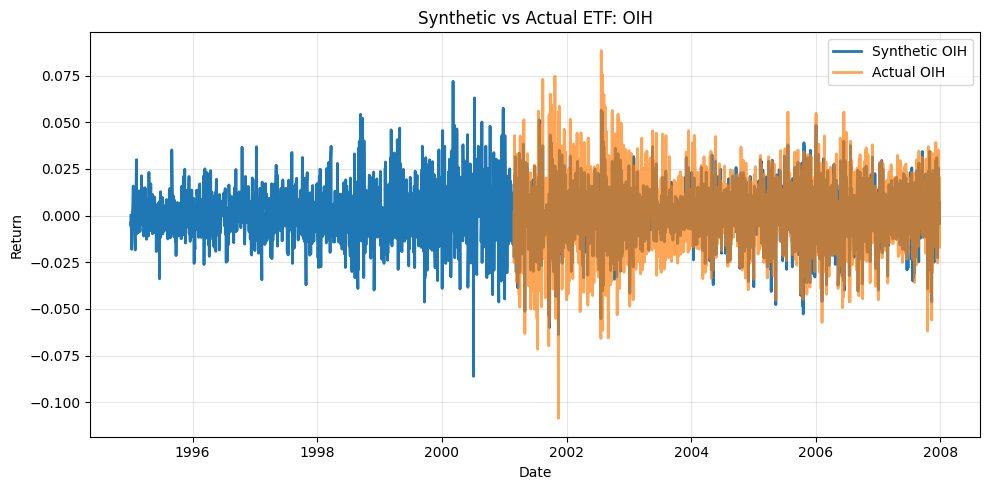

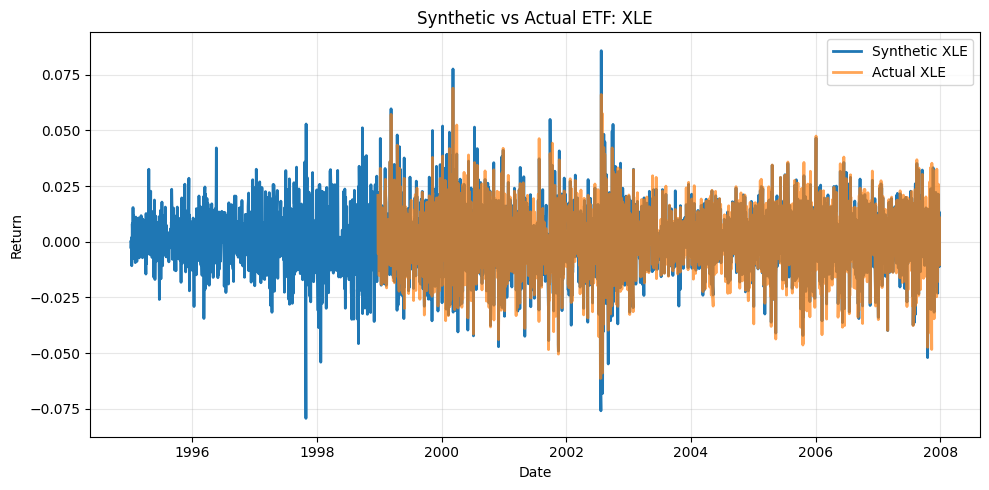

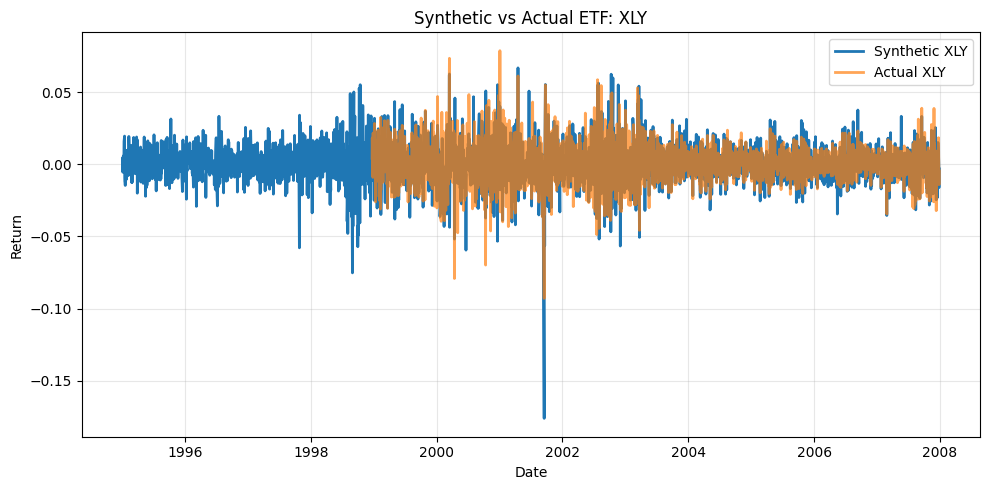

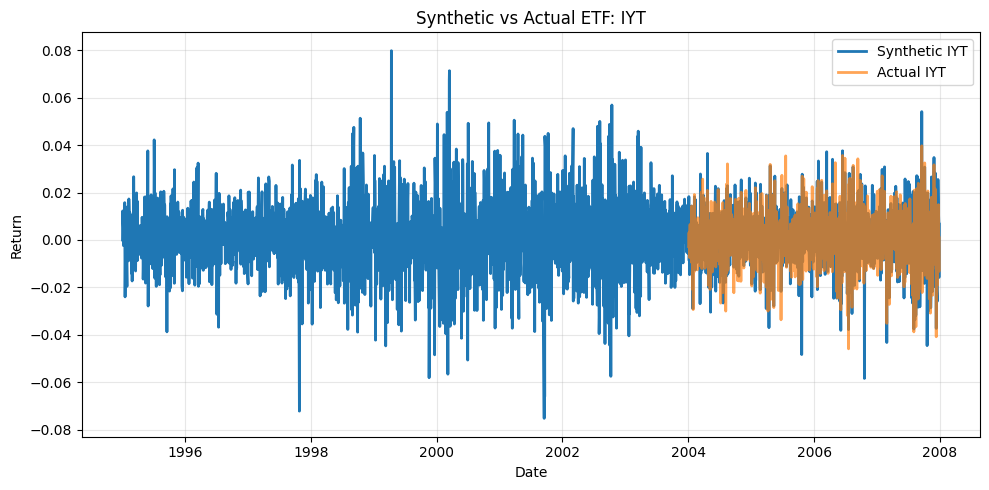

In [28]:
# 1. Tìm giao tên ETF giữa synthetic và actual
common_etfs = sector_returns.columns.intersection(etf_df.columns)

print("Common ETFs:", list(common_etfs))

# 2. Vẽ từng ETF một
for etf in common_etfs:
    plt.figure(figsize=(10, 5))
    
    plt.plot(sector_returns.index, sector_returns[etf], label=f"Synthetic {etf}", linewidth=2)
    plt.plot(etf_returns.index, etf_returns[etf], label=f"Actual {etf}", linewidth=2, alpha=0.7)
    
    plt.title(f"Synthetic vs Actual ETF: {etf}")
    plt.xlabel("Date")
    plt.ylabel("Return")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### BACKTEST

#### SYNTHETIC ETFs as factors

In [29]:
ticker_to_etf = dict(
    zip(stock_map_etf["Ticker"], stock_map_etf["Sector_ETF"])
)

In [30]:
ticker_to_etf

{'MMM': 'XLI',
 'AOS': 'XLI',
 'ABT': 'XLV',
 'ACN': 'XLK',
 'ADBE': 'XLK',
 'AMD': 'SMH',
 'AES': 'UTH',
 'AFL': 'XLF',
 'A': 'XLV',
 'APD': 'XLI',
 'AKAM': 'XLK',
 'ALB': 'XLI',
 'ARE': 'IYR',
 'ALGN': 'XLV',
 'LNT': 'UTH',
 'ALL': 'XLF',
 'GOOGL': 'HHH',
 'GOOG': 'HHH',
 'MO': 'XLP',
 'AMZN': 'RTH',
 'AEE': 'UTH',
 'AEP': 'UTH',
 'AXP': 'XLF',
 'AIG': 'XLF',
 'AMT': 'IYR',
 'AMP': 'XLF',
 'AME': 'XLI',
 'AMGN': 'XLV',
 'APH': 'XLK',
 'ADI': 'SMH',
 'AON': 'XLF',
 'APA': 'OIH',
 'AAPL': 'XLK',
 'AMAT': 'SMH',
 'ACGL': 'XLF',
 'ADM': 'XLP',
 'AJG': 'XLF',
 'AIZ': 'XLF',
 'T': 'HHH',
 'ATO': 'UTH',
 'ADSK': 'XLK',
 'ADP': 'XLI',
 'AZO': 'RTH',
 'AVB': 'IYR',
 'AVY': 'XLI',
 'AXON': 'XLI',
 'BKR': 'XLE',
 'BALL': 'XLI',
 'BAC': 'XLF',
 'BAX': 'XLV',
 'BDX': 'XLV',
 'BRK-B': 'XLF',
 'BBY': 'RTH',
 'TECH': 'XLV',
 'BIIB': 'XLV',
 'BLK': 'XLF',
 'BX': 'XLF',
 'BK': 'XLF',
 'BA': 'XLI',
 'BKNG': 'XLY',
 'BSX': 'XLV',
 'BMY': 'XLV',
 'BR': 'XLI',
 'BRO': 'XLF',
 'BF-B': 'XLP',
 'BLDR': 'XLI'

Regress factors -> extract residuals

In [31]:
def compute_residuals(returns_filtered,
                      sector_returns,
                      ticker_to_etf,
                      window=60):

    idx = returns_filtered.index.intersection(sector_returns.index)

    returns_filtered = returns_filtered.loc[idx]
    sector_returns = sector_returns.loc[idx]

    residuals = pd.DataFrame(index=idx,
                             columns=returns_filtered.columns,
                             dtype=float)

    for ticker in returns_filtered.columns:

        if ticker not in ticker_to_etf:
            continue

        sector = ticker_to_etf[ticker]
        if sector not in sector_returns.columns:
            continue

        r = returns_filtered[ticker]
        F = sector_returns[sector]

        # Rolling moments
        cov = r.rolling(window).cov(F)
        var = F.rolling(window).var()

        beta = cov / var
        alpha = r.rolling(window).mean() - beta * F.rolling(window).mean()

        residuals[ticker] = r - (alpha + beta * F)

    return residuals

In [32]:
def cumulative_residuals(residuals):
    X = residuals.cumsum()
    return X

In [33]:
def fit_ou(X, window=60):

    kappa = pd.DataFrame(index=X.index, columns=X.columns, dtype=float)
    mu = kappa.copy()
    sigma_eq = kappa.copy()

    for t in range(window, len(X)):

        date = X.index[t]
        X_window = X.iloc[t-window:t]

        m_list = []

        for ticker in X.columns:

            series = X_window[ticker].dropna()
            if len(series) < window:
                continue

            x = series.values

            x_lag = x[:-1]
            x_now = x[1:]

            if len(x_lag) < 2:
                continue

            var_lag = np.var(x_lag, ddof=1)
            if var_lag <= 1e-12:
                continue

            cov = np.cov(x_lag, x_now, ddof=1)[0, 1]

            b = cov / var_lag

            if b <= 0 or b >= 1:
                continue

            # discrete → continuous
            k = -np.log(b)

            # annualization filter
            k_annual = k * 252
            if k_annual < 8.4:
                continue

            a = x_now.mean() - b * x_lag.mean()
            m = a / (1 - b)

            eps = x_now - (a + b * x_lag)
            sigma = np.std(eps, ddof=1) * np.sqrt(252)

            sigma_eq_val = sigma / np.sqrt(2 * k_annual)

            kappa.loc[date, ticker] = k_annual
            mu.loc[date, ticker] = m
            sigma_eq.loc[date, ticker] = sigma_eq_val

            m_list.append(m)

        # Cross-sectional mean adjustment (Eq 18)
        if m_list:
            cross_mean = np.mean(m_list)
            valid = mu.loc[date].notna()
            mu.loc[date, valid] -= cross_mean

    return kappa, mu, sigma_eq

In [34]:
def compute_s_score(X, mu, sigma_eq):

    s = (X - mu) / sigma_eq
    return s

In [35]:
def generate_signals(s, s_open=1.25, s_close_long=0.5, s_close_short=0.75):

    signals = pd.DataFrame(0, index=s.index, columns=s.columns)
    current = pd.Series(0, index=s.columns)

    for t in range(1, len(s)):

        yesterday = s.iloc[t-1]
        new_pos = current.copy()

        # --- ENTRY ---
        open_long = yesterday < -s_open
        open_short = yesterday > s_open

        new_pos[open_long] = 1
        new_pos[open_short] = -1

        # --- EXIT ---
        close_long = (current == 1) & (yesterday > -s_close_long)
        close_short = (current == -1) & (yesterday < s_close_short)

        new_pos[close_long] = 0
        new_pos[close_short] = 0

        signals.iloc[t] = new_pos
        current = new_pos

    return signals

In [36]:
def construct_portfolio(signals, leverage=2):

    weights = pd.DataFrame(
        0.0,
        index=signals.index,
        columns=signals.columns
    )

    for date in signals.index:

        longs = signals.loc[date] == 1
        shorts = signals.loc[date] == -1

        n_long = longs.sum()
        n_short = shorts.sum()

        if n_long > 0:
            weights.loc[date, longs] = leverage/ n_long

        if n_short > 0:
            weights.loc[date, shorts] = -leverage/ n_short

    return weights

In [37]:
def compute_portfolio_beta(weights, returns_filtered, spy_returns, window=60):

    port_ret = (weights * returns_filtered).sum(axis=1)

    cov = port_ret.rolling(window).cov(spy_returns)
    var = spy_returns.rolling(window).var()

    beta = cov / var

    return beta

In [38]:
def backtest_engine(weights,
                    returns_filtered,
                    spy_returns,
                    window=60,
                    initial_equity=1_000_000,
                    slippage=0.001):

    weights = weights.shift(1)

    common = weights.index \
        .intersection(returns_filtered.index) \
        .intersection(spy_returns.index)

    weights = weights.loc[common].fillna(0)
    returns_filtered = returns_filtered.loc[common].fillna(0)
    spy_returns = spy_returns.loc[common].fillna(0)

    # ---- Portfolio raw return (before hedge) ----
    port_ret = (weights * returns_filtered).sum(axis=1)

    # ---- Rolling beta of portfolio ----
    cov = port_ret.rolling(window).cov(spy_returns)
    var = spy_returns.rolling(window).var()

    beta = cov / var
    beta = beta.fillna(0)

    equity = pd.Series(index=common, dtype=float)
    equity.iloc[0] = initial_equity

    prev_w = pd.Series(0.0, index=weights.columns)
    prev_hedge = 0.0

    for t in range(1, len(common)):

        w = weights.iloc[t]
        r = returns_filtered.iloc[t]
        r_spy = spy_returns.iloc[t]

        hedge_w = -beta.iloc[t-1]

        # ---- Returns ----
        stock_ret = np.nansum(w.values * r.values)
        hedge_ret = hedge_w * r_spy

        gross_ret = stock_ret + hedge_ret

        # ---- Turnover ----
        turnover = np.nansum(np.abs(w.values - prev_w.values)) \
                   + abs(hedge_w - prev_hedge)

        cost = turnover * slippage

        net_ret = gross_ret - cost

        equity.iloc[t] = equity.iloc[t-1] * (1 + net_ret)

        prev_w = w
        prev_hedge = hedge_w

    return equity

In [ ]:
# ==============================
# 1️⃣ RUN PIPELINE
# ==============================

# Residuals (sector only)
residuals = compute_residuals(
    returns_filtered,
    sector_returns,
    ticker_to_etf,
    window=60
)

# Cumulative residual process
X = cumulative_residuals(residuals)

# OU parameters
kappa, mu, sigma_eq = fit_ou(X, window=60)

# s-score
s = compute_s_score(X, mu, sigma_eq)

# Trading signals
signals = generate_signals(
    s,
    s_open=1.25,
    s_close_long=0.5,
    s_close_short=0.75
)

# Portfolio construction (2+2 leverage)
weights = construct_portfolio(signals, leverage=2)

# Backtest
equity = backtest_engine(
    weights,
    returns_filtered,
    spy_returns,
    window=60,
    initial_equity=1_000_000,
    slippage=0.0005
)

equity = equity.dropna()

# ==============================
# 2️⃣ PERFORMANCE METRICS
# ==============================

# Daily returns
strategy_returns = equity.pct_change().dropna()

# Annualization factor
ann_factor = 252

# Sharpe ratio (risk-free = 0)
sharpe = np.sqrt(ann_factor) * strategy_returns.mean() / strategy_returns.std()

# Annualized volatility
vol = strategy_returns.std() * np.sqrt(ann_factor)


# ==============================
# 3️⃣ PRINT RESULTS
# ==============================

print("Final Equity:", round(equity.iloc[-1], 2))
print("Sharpe Ratio:", round(sharpe, 3))
print("Annual Volatility:", round(vol, 3))

In [ ]:
# ==============================
# 1. Prepare returns
# ==============================

portfolio_returns = equity.pct_change().dropna()
sector_returns = sector_returns.dropna(how="all")

# ==============================
# 2. Yearly Sharpe function
# ==============================

def yearly_sharpe(returns, rf=0):
    
    result = {}
    
    for year, data in returns.groupby(returns.index.year):
        
        if len(data) < 30:
            continue
        
        mu = data.mean() * 252
        sigma = data.std() * np.sqrt(252)
        
        sharpe = np.nan if sigma == 0 else (mu - rf) / sigma
        
        result[year] = sharpe
    
    return pd.Series(result)


# ==============================
# 3. Full period Sharpe
# ==============================

def full_sharpe(returns):
    
    mu = returns.mean() * 252
    sigma = returns.std() * np.sqrt(252)
    
    return np.nan if sigma == 0 else mu / sigma


# ==============================
# 4. Compute Sharpe table
# ==============================

sharpe_table = {}

# Synthetic ETFs
for col in sector_returns.columns:
    sharpe_table[col] = yearly_sharpe(sector_returns[col].dropna())

# Portfolio
sharpe_table["Portfolio"] = yearly_sharpe(portfolio_returns)

sharpe_df = pd.DataFrame(sharpe_table)

# ==============================
# 5. Since inception row
# ==============================

since = {}

for col in sector_returns.columns:
    since[col] = full_sharpe(sector_returns[col].dropna())

since["Portfolio"] = full_sharpe(portfolio_returns)

sharpe_df.loc["Since inception"] = since

# ==============================
# 6. Keep 1996–2007 only
# ==============================

year_rows = sharpe_df.loc[
    sharpe_df.index.map(lambda x: isinstance(x, int))
]

year_rows = year_rows[(year_rows.index >= 1996) & (year_rows.index <= 2007)]

since_row = sharpe_df.loc[["Since inception"]]

sharpe_df = pd.concat([year_rows.sort_index(), since_row])

# ==============================
# 7. Format output
# ==============================

sharpe_df = sharpe_df.round(1)

print(sharpe_df)

                 XLI  XLV  XLK  SMH  UTH  XLF  XLY  IYR  HHH  XLP  RTH  OIH  \
1996             2.0  1.2  1.7  1.1 -0.3  1.8  1.5  2.7  0.4  1.7  0.5  1.4   
1997             1.1  1.6  0.9  0.2  2.9  1.9  2.0  1.2  2.1  1.7  2.2  0.7   
1998             0.6  1.5  2.1  1.4  0.9  0.6  1.8 -0.2  1.1  1.1  2.1 -0.9   
1999             1.3 -0.2  2.2  1.7 -1.2  1.1  0.1 -0.1  0.7  0.8  1.5  0.8   
2000             0.4  1.3 -0.7 -0.2  1.5  0.9 -0.5  1.2 -0.2 -0.1 -0.4  1.6   
2001            -0.2 -0.6 -0.1  0.2 -0.6 -0.3 -0.4  1.4 -0.4  0.0  0.9 -0.3   
2002            -0.7 -0.5 -0.5 -0.9 -0.6 -0.4 -0.6  0.5 -0.5 -0.3 -1.1  0.2   
2003             1.8  1.1  1.1  2.0  2.0  1.3  2.4  2.6  0.8  1.0  1.6  2.0   
2004             1.3  0.2  0.5 -0.1  1.6  0.5  2.0  1.6  1.0  0.8  0.9  1.7   
2005             0.5  0.4  0.4  0.7  1.1  0.5 -0.4  0.7 -1.3  0.2  0.3  1.5   
2006             1.1  0.8  1.4 -0.5  2.0  1.4  0.4  2.2  2.9  1.3  0.2  0.6   
2007             0.9  0.7  1.3 -0.0  0.7 -1.1 -0.1 -

In [ ]:
equity_index = 100 * equity / equity.iloc[0]

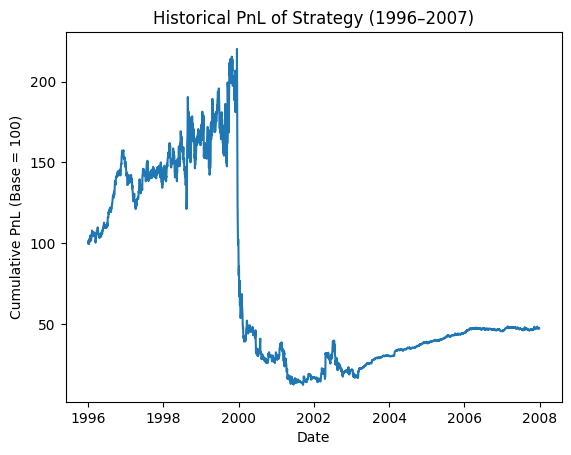

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(equity_index)

plt.title("Historical PnL of Strategy (1996–2007)")
plt.xlabel("Date")
plt.ylabel("Cumulative PnL (Base = 100)")

plt.show()

In [ ]:
print(portfolio_returns.min())
print(portfolio_returns.nsmallest(5))

-0.25417711773293217
Date
2001-03-22   -0.254177
1999-12-20   -0.247724
2000-08-01   -0.215412
2001-04-18   -0.214795
2000-01-03   -0.201393
dtype: float64


#### Tải Spy returns

In [ ]:
# import yfinance as yf
# import pandas as pd

# # Tải dữ liệu SPY
# spy = yf.download("SPY",
#                   start="1996-01-01",
#                   end="2008-01-01",
#                   auto_adjust=True)

# # Giữ Adjusted Close
# spy_prices = spy["Close"]

# # Tính daily returns
# spy_returns = spy_prices.pct_change()

# # Bỏ dòng NaN đầu tiên
# spy_returns = spy_returns.dropna()

# print(spy_returns.head())


In [ ]:
# spy_returns.to_csv("spy_returns_1996_2007.csv")
# print("Saved to spy_returns_1996_2007.csv")

In [ ]:
# common_index = returns_filtered.index \
#     .intersection(sector_returns.index) \
#     .intersection(spy_returns.index)
# #
# returns_filtered = returns_filtered.loc[common_index]
# sector_returns = sector_returns.loc[common_index]
# spy_returns = spy_returns.loc[common_index]

### ACTUAL ETFs

In [ ]:
etf_returns.head()

,FDN,IYR,IYT,KRE,OIH,SMH,XLE,XLF,XLI,XLK,XLP,XLU,XLV,XLY,XRT
Date,,,,,,,,,,,,,,,
1998-12-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1998-12-23,NaN,NaN,NaN,NaN,NaN,NaN,0.020819,0.014745,0.017450,0.023891,0.024175,-0.004190,0.022472,0.004294,NaN
1998-12-24,NaN,NaN,NaN,NaN,NaN,NaN,-0.005263,0.006605,0.013192,-0.003810,-0.001728,0.018411,0.006106,0.018327,NaN
1998-12-28,NaN,NaN,NaN,NaN,NaN,NaN,-0.005290,-0.013123,0.005208,0.002868,-0.005767,-0.005165,-0.014564,-0.008998,NaN
1998-12-29,NaN,NaN,NaN,NaN,NaN,NaN,0.009973,0.010638,0.014249,0.002860,0.022042,0.016615,0.022168,0.021792,NaN


In [ ]:
start_date = "2002-01-01"
etf_returns = etf_returns.loc[start_date:]
returns_filtered = returns_filtered.loc[start_date:]

In [ ]:
def compute_residuals_actual_etf(stock_returns,
                                 etf_returns,
                                 stock_to_etf,
                                 min_obs=60):

    residuals = pd.DataFrame(index=stock_returns.index,
                             columns=stock_returns.columns,
                             dtype=float)

    for stock in stock_returns.columns:

        etf = stock_to_etf.get(stock)

        if etf not in etf_returns.columns:
            continue

        y = stock_returns[stock]
        x = etf_returns[etf]

        # align index
        df = pd.concat([y, x], axis=1, join='inner')
        df.columns = ['y', 'x']

        # drop NaN + inf
        df = df.replace([np.inf, -np.inf], np.nan).dropna()

        if len(df) < min_obs:
            continue

        # kiểm tra variance ETF != 0
        if df['x'].std() < 1e-8:
            continue

        X = np.column_stack([np.ones(len(df)), df['x'].values])
        Y = df['y'].values

        try:
            beta = np.linalg.lstsq(X, Y, rcond=None)[0]
        except np.linalg.LinAlgError:
            continue

        y_hat = X @ beta
        resid = Y - y_hat

        residuals.loc[df.index, stock] = resid

    return residuals

In [ ]:
residuals = compute_residuals_actual_etf(
    returns_filtered,
    etf_returns,
    ticker_to_etf
)

In [ ]:
signals = generate_signals(residuals)

In [ ]:
weights_actual = construct_portfolio(signals, leverage=2)

In [ ]:
def compute_industry_hedge(weights, stock_to_etf):

    etf_list = list(set(stock_to_etf.values()))

    hedge_weights = pd.DataFrame(
        0.0,
        index=weights.index,
        columns=etf_list
    )

    for stock in weights.columns:

        etf = stock_to_etf.get(stock)

        if etf is None or etf not in hedge_weights.columns:
            continue

        hedge_weights[etf] -= weights[stock]

    return hedge_weights

In [ ]:
hedge_weights = compute_industry_hedge(weights_actual, ticker_to_etf)

In [ ]:
def backtest_actual_etf(weights,
                        hedge_weights,
                        stock_returns,
                        etf_returns,
                        initial_equity=1_000_000,
                        slippage=0.0005):

    common = weights.index \
        .intersection(stock_returns.index) \
        .intersection(etf_returns.index)

    weights = weights.loc[common]
    hedge_weights = hedge_weights.loc[common]
    stock_returns = stock_returns.loc[common]
    etf_returns = etf_returns.loc[common]

    equity = pd.Series(initial_equity, index=common)

    prev_w = weights.iloc[0]
    prev_h = hedge_weights.iloc[0]

    for t in range(1, len(common)):

        w = weights.iloc[t-1]
        h = hedge_weights.iloc[t-1]

        r_stock = stock_returns.iloc[t]
        r_etf = etf_returns.iloc[t]

        stock_pnl = equity.iloc[t-1] * np.nansum(w * r_stock)
        hedge_pnl = equity.iloc[t-1] * np.nansum(h * r_etf)

        pnl = stock_pnl + hedge_pnl

        turnover = (weights.iloc[t] - prev_w).abs().sum() \
                   + (hedge_weights.iloc[t] - prev_h).abs().sum()

        cost = equity.iloc[t-1] * turnover * slippage

        equity.iloc[t] = equity.iloc[t-1] + pnl - cost

        prev_w = weights.iloc[t]
        prev_h = hedge_weights.iloc[t]

    return equity

In [ ]:
equity_actual = backtest_actual_etf(
    weights,
    hedge_weights,
    returns_filtered,
    etf_returns
)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_7220\125333413.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1011327.0714996677' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  equity.iloc[t] = equity.iloc[t-1] + pnl - cost


In [ ]:
portfolio_returns_actual = equity_actual.pct_change().dropna()

sharpe = portfolio_returns_actual.mean() * 252 / \
         (portfolio_returns_actual.std() * np.sqrt(252))

print("Final Equity:", equity_actual.iloc[-1])
print("Sharpe:", sharpe)

Final Equity: 8948146.263880624
Sharpe: 1.0374024643051485


In [ ]:
import numpy as np
import pandas as pd

# Ghép portfolio vào ETF returns
combined = etf_returns.copy()
combined["Portfolio"] = portfolio_returns_actual

# Hàm tính annualized Sharpe
def annual_sharpe(x):
    x = x.dropna()
    if len(x) > 20 and x.std() > 0:
        return (x.mean() * 252) / (x.std() * np.sqrt(252))
    return np.nan

# Tính Sharpe theo từng năm
sharpe_table = (
    combined
    .loc['2002-01-01':'2007-12-31']   # nếu bạn muốn giới hạn giai đoạn
    .groupby(combined.loc['2002-01-01':'2007-12-31'].index.year)
    .apply(lambda df: df.apply(annual_sharpe))
)

print(sharpe_table.round(2))

       FDN   IYR   IYT   KRE   OIH   SMH   XLE   XLF   XLI   XLK   XLP   XLU  \
Date                                                                           
2002   NaN  0.30   NaN   NaN  0.08 -0.77 -0.41 -0.36 -0.85 -0.94 -1.06 -0.89   
2003   NaN  2.57   NaN   NaN  0.45  1.87  1.51  1.45  1.65  1.42  0.85  1.50   
2004   NaN  1.59  1.57   NaN  1.40 -0.58  1.73  0.90  1.34  0.40  0.79  1.84   
2005   NaN  0.61  0.67   NaN  1.64  0.56  1.45  0.56  0.29  0.03  0.35  1.12   
2006  1.01  2.06  0.53  0.93  0.43 -0.25  0.79  1.55  1.12  0.88  1.60  1.74   
2007  0.66 -0.68  0.21 -0.83  1.56 -0.05  1.44 -0.77  0.90  1.01  1.24  1.15   

       XLV   XLY   XRT  Portfolio  
Date                               
2002  0.10 -0.57   NaN       0.86  
2003  0.93  1.64   NaN       1.91  
2004  0.16  1.00   NaN       2.02  
2005  0.65 -0.46   NaN       1.08  
2006  0.73  1.50  1.06       1.62  
2007  0.66 -0.74 -0.69       0.51  


In [ ]:
since_inception = combined.loc['2002-01-01':'2007-12-31'].apply(annual_sharpe)

sharpe_table.loc["Since inception"] = since_inception

print(sharpe_table.round(2))

                  FDN   IYR   IYT   KRE   OIH   SMH   XLE   XLF   XLI   XLK  \
Date                                                                          
2002              NaN  0.30   NaN   NaN  0.08 -0.77 -0.41 -0.36 -0.85 -0.94   
2003              NaN  2.57   NaN   NaN  0.45  1.87  1.51  1.45  1.65  1.42   
2004              NaN  1.59  1.57   NaN  1.40 -0.58  1.73  0.90  1.34  0.40   
2005              NaN  0.61  0.67   NaN  1.64  0.56  1.45  0.56  0.29  0.03   
2006             1.01  2.06  0.53  0.93  0.43 -0.25  0.79  1.55  1.12  0.88   
2007             0.66 -0.68  0.21 -0.83  1.56 -0.05  1.44 -0.77  0.90  1.01   
Since inception  0.78  0.84  0.70 -0.45  0.82  0.05  0.97  0.29  0.51  0.23   

                  XLP   XLU   XLV   XLY   XRT  Portfolio  
Date                                                      
2002            -1.06 -0.89  0.10 -0.57   NaN       0.86  
2003             0.85  1.50  0.93  1.64   NaN       1.91  
2004             0.79  1.84  0.16  1.00   NaN       

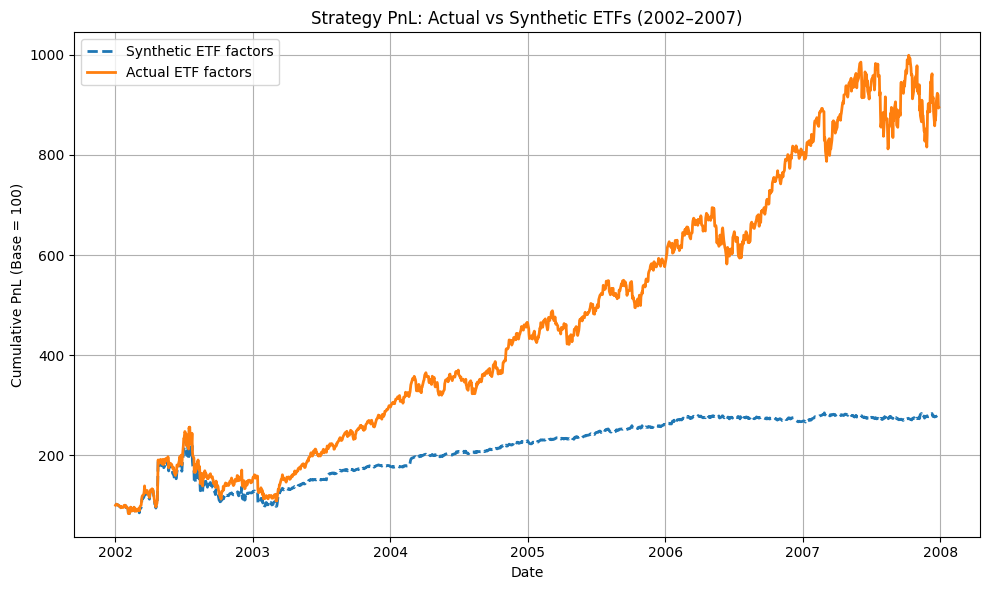

In [ ]:
# Cắt giai đoạn 2002–2007
eq_syn = equity.loc['2002-01-01':'2007-12-31']
eq_act = equity_actual.loc['2002-01-01':'2007-12-31']

# Rebase về 100
eq_syn = 100 * eq_syn / eq_syn.iloc[0]
eq_act = 100 * eq_act / eq_act.iloc[0]

# Plot
plt.figure(figsize=(10,6))

plt.plot(eq_syn.index, eq_syn,
         linestyle='--',
         linewidth=2,
         label='Synthetic ETF factors')

plt.plot(eq_act.index, eq_act,
         linestyle='-',
         linewidth=2,
         label='Actual ETF factors')

plt.title('Strategy PnL: Actual vs Synthetic ETFs (2002–2007)')
plt.ylabel('Cumulative PnL (Base = 100)')
plt.xlabel('Date')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# .

In [1]:
import pandas as pd

In [4]:
df = pd.read_csv(r"C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\VNdata\vietnam_stock_price_full.csv", index_col=0, parse_dates=True)
volume_df = pd.read_csv(r"C:\Assigment\2025-2026\Quantitative Finance\Statistical_arbitrage_replication\VNdata\vietnam_stock_volume_full.csv", index_col=0, parse_dates=True)

In [3]:
df.index

DatetimeIndex(['2014-07-09', '2014-07-10', '2014-07-11', '2014-07-14',
               '2014-07-15', '2014-07-16', '2014-07-17', '2014-07-18',
               '2014-07-21', '2014-07-22',
               ...
               '2025-12-18', '2025-12-19', '2025-12-22', '2025-12-23',
               '2025-12-24', '2025-12-25', '2025-12-26', '2025-12-29',
               '2025-12-30', '2025-12-31'],
              dtype='datetime64[ns]', length=2872, freq=None)

In [ ]:
df.loc

In [46]:
df.index.get_loc("2014-07-09")

0

In [68]:
df.loc[(pd.to_datetime("2018-01-02") - pd.Timedelta(days=365)):pd.to_datetime("2018-01-02")]

,YEG,YBM,X20,WSS,WCS,VVS,VTZ,VTV,VTP,VTO,...,ACG,ACC,ACB,ABT,ABS,ABR,AAV,AAT,AAM,AAA
2017-01-03,NaN,NaN,NaN,4.4,78.22,NaN,NaN,11.99,NaN,3.53,...,NaN,6.94,3.33,24.82,NaN,NaN,NaN,NaN,5.78,12.94
2017-01-04,NaN,NaN,NaN,4.5,77.16,NaN,NaN,11.92,NaN,3.52,...,NaN,6.83,3.35,24.82,NaN,NaN,NaN,NaN,6.10,13.10
2017-01-05,NaN,NaN,NaN,4.4,78.44,NaN,NaN,11.86,NaN,3.45,...,NaN,6.83,3.35,24.82,NaN,NaN,NaN,NaN,5.70,13.36
2017-01-06,NaN,NaN,NaN,4.4,76.32,NaN,NaN,11.80,NaN,3.52,...,NaN,6.86,3.53,24.82,NaN,NaN,NaN,NaN,6.10,12.89
2017-01-09,NaN,NaN,NaN,4.5,76.32,NaN,NaN,11.74,NaN,3.60,...,NaN,6.83,3.65,24.82,NaN,NaN,NaN,NaN,6.27,13.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-26,NaN,NaN,NaN,4.1,69.02,NaN,NaN,10.95,NaN,4.26,...,NaN,4.92,6.09,16.97,NaN,NaN,NaN,NaN,5.92,18.21
2017-12-27,NaN,NaN,NaN,4.0,68.59,NaN,NaN,10.95,NaN,4.33,...,NaN,4.89,6.41,17.30,NaN,NaN,NaN,NaN,6.33,18.18
2017-12-28,NaN,NaN,NaN,4.0,68.59,NaN,NaN,10.89,NaN,4.28,...,NaN,4.89,6.46,17.18,NaN,NaN,NaN,NaN,6.33,18.18
2017-12-29,NaN,NaN,NaN,4.0,68.59,NaN,NaN,10.56,NaN,4.28,...,NaN,4.84,6.48,17.77,NaN,NaN,NaN,NaN,6.18,18.38


In [18]:
df['SHB']

2014-07-09     2.48
2014-07-10     2.43
2014-07-11     2.45
2014-07-14     2.43
2014-07-15     2.43
              ...  
2025-12-25    16.50
2025-12-26    16.35
2025-12-29    16.20
2025-12-30    16.35
2025-12-31    16.35
Name: SHB, Length: 2872, dtype: float64

In [1]:
import pandas as pd

In [2]:
def top_liquidity_stocks(price_df, volume_df, top_n=300, average_window=60):
    # Calculate liquidity metrics (average volume* price over lookback window)
    price_win = price_df.tail(average_window)
    volume_win = volume_df.tail(average_window)

    liquidity = (price_win * volume_win).mean()
    top_stocks = liquidity.nlargest(min(top_n, len(liquidity))).index

    return price_df[top_stocks], volume_df[top_stocks].astype(float)

# --- Fill missing values with average of 2 before and 2 after ---
def fill_na_with_2before_2after(df: pd.DataFrame, min_neighbors=1, require_all=False):
    s1 = df.shift(1)
    s2 = df.shift(2)
    s_1 = df.shift(-1)
    s_2 = df.shift(-2)

    neighbor_sum = s1.fillna(0) + s2.fillna(0) + s_1.fillna(0) + s_2.fillna(0)
    neighbor_count = (
        s1.notna().astype(int)
        + s2.notna().astype(int)
        + s_1.notna().astype(int)
        + s_2.notna().astype(int)
    )

    neighbor_mean = neighbor_sum / neighbor_count.where(neighbor_count > 0)

    if require_all:
        fill_values = neighbor_mean.where(neighbor_count == 4)
    else:
        fill_values = neighbor_mean.where(neighbor_count >= min_neighbors)

    return df.where(df.notna(), fill_values)

# --- Universe selection based on liquidity ---
def select_universe(prices_df: pd.DataFrame, volume_df: pd.DataFrame, date: pd.Timestamp, top_n=300, lookback_window=366):
    # filter stocks with price data on the given date
    list_stocks_notna_today = prices_df.loc[date].notna()
    price = prices_df.loc[(date - pd.Timedelta(days=lookback_window)):date, list_stocks_notna_today]
    volume = volume_df.loc[(date - pd.Timedelta(days=lookback_window)):date, list_stocks_notna_today]

    # common columns
    common_columns = price.columns.intersection(volume.columns)
    price = price[common_columns]
    volume = volume[common_columns]

    # handle missing values by forward fill then drop na
    price = price.ffill(limit=2)
    price = price.dropna(axis=1, how='any')
    columns = price.columns
    volume = volume[columns]
    # fill volume missing values with average of previous and next valid values
    volume = fill_na_with_2before_2after(volume, min_neighbors=1, require_all=False)
    volume = volume.dropna(axis=1, how='any')
    columns = volume.columns
    price = price[columns]
    
    # return price and volume for the top N stocks by liquidity
    return top_liquidity_stocks(price, volume, top_n=top_n, average_window=lookback_window)

# --- Returns calculation ---
def compute_returns(price_df, volume_df=None, with_volume=False, volume_average_window=10):
    returns = price_df.pct_change().dropna()
    if with_volume and volume_df is not None:
        volume_average = volume_df.shift(1).rolling(volume_average_window).mean().dropna()
        volume_average = volume_average.reindex(returns.index)
        delta_volume = volume_df.diff().dropna()
        returns = returns*(volume_average/delta_volume)
        return returns, volume_average, delta_volume
    return returns

In [5]:
df_example, volume_example = select_universe(df, volume_df, pd.to_datetime("2019-01-02"), top_n=300, lookback_window=366)

In [6]:
df_example

,STB,VJC,PVS,CTG,VRE,VIC,VNM,VCB,MSN,HPG,...,PGI,INN,VE1,ICG,HMC,VSI,C69,PV2,HKT,CTF
2018-01-02,13.40,118.84,15.52,11.42,37.54,28.72,100.65,23.24,64.74,9.04,...,11.06,20.46,17.3,4.48,4.69,6.83,4.18,2.6,2.73,7.92
2018-01-03,13.35,119.49,17.07,11.35,37.58,29.57,101.79,23.20,66.76,9.02,...,10.93,20.00,17.6,4.41,4.52,6.78,4.25,2.6,2.91,7.92
2018-01-04,13.60,119.97,17.27,11.76,37.42,29.75,102.22,23.41,66.76,9.13,...,10.98,20.43,19.3,4.41,4.59,6.78,4.18,2.7,2.91,7.92
2018-01-05,13.60,119.97,17.61,11.49,37.26,29.38,101.60,22.82,68.54,9.09,...,11.19,20.33,17.4,4.41,4.59,6.78,4.25,2.7,3.00,7.92
2018-01-08,14.55,119.65,18.21,11.76,36.79,29.49,99.94,23.41,71.86,9.38,...,11.19,19.97,17.6,4.41,4.83,6.76,4.05,2.7,2.91,7.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-25,11.95,120.84,13.35,9.02,28.94,45.29,72.70,22.56,64.74,8.06,...,11.00,14.08,8.9,6.52,5.98,12.88,3.74,3.1,2.40,12.14
2018-12-26,11.95,120.94,12.97,8.83,28.36,45.29,72.35,22.60,63.93,8.04,...,11.00,14.08,9.0,6.59,5.98,13.14,3.74,3.1,2.40,12.14
2018-12-27,12.00,118.96,13.43,8.86,28.36,45.51,72.47,22.90,63.93,8.21,...,10.55,14.08,9.3,6.52,6.04,13.40,3.74,3.1,2.40,12.14
2018-12-28,11.95,118.96,13.35,8.83,27.10,42.36,70.59,22.90,62.71,8.21,...,10.05,14.08,9.3,6.52,6.06,13.19,3.74,3.1,2.30,12.14


In [30]:
returns_60_df = df_example.loc[df_example.index[-60:]]
returns_60_df

,HPG,STB,MBB,SCR,VCG,CTG,KBC,VRE,SHB,OGC,...,MCH,DVP,DSN,CSC,HTV,CMX,NNC,NHH,PTI,HRC
2018-10-09,10.88,13.55,6.04,7.47,10.71,12.22,9.34,31.16,2.87,2.89,...,30.66,25.10,33.91,6.78,9.83,4.59,32.39,13.76,10.56,34.20
2018-10-10,10.98,13.40,5.96,7.45,10.94,12.10,9.20,31.71,2.84,2.85,...,30.32,23.62,33.46,7.00,9.60,4.27,32.39,13.76,10.56,34.20
2018-10-11,10.58,12.50,5.57,6.93,10.25,11.26,8.56,29.65,2.60,2.66,...,30.66,23.01,33.18,6.57,9.99,4.57,31.81,13.76,10.56,35.69
2018-10-12,10.82,13.05,5.71,7.11,10.42,11.62,8.84,30.17,2.74,2.71,...,29.53,23.01,33.18,7.23,9.89,4.59,31.81,13.76,10.56,34.79
2018-10-15,10.70,12.95,5.58,6.97,10.48,11.33,8.84,29.18,2.67,2.73,...,29.53,23.34,33.40,7.94,9.89,4.27,32.00,13.76,9.97,34.79
2018-10-16,10.81,13.60,5.70,7.02,10.54,11.51,8.92,29.49,2.70,2.83,...,29.57,23.39,33.91,8.71,9.54,4.17,32.20,13.76,9.97,34.20
2018-10-17,10.88,13.55,5.67,7.08,10.60,11.58,8.99,29.81,2.74,2.83,...,29.57,23.31,33.91,9.58,9.67,4.17,32.45,13.76,10.44,34.10
2018-10-18,10.88,13.50,5.54,7.01,10.71,11.37,8.84,29.46,2.67,2.80,...,29.84,23.01,34.03,8.73,9.02,4.38,32.58,13.76,9.68,34.10
2018-10-19,10.81,13.45,5.50,6.97,10.77,11.30,8.81,29.38,2.67,2.78,...,29.19,23.01,34.03,9.44,9.60,4.59,32.39,13.46,10.15,34.10
2018-10-22,10.64,12.95,5.53,6.81,10.65,11.19,8.74,29.73,2.64,2.79,...,29.22,23.01,33.97,9.16,10.15,4.88,32.39,13.46,9.39,31.71


In [24]:
df_example

,HPG,STB,MBB,SCR,VCG,CTG,KBC,VRE,SHB,OGC,...,MCH,DVP,DSN,CSC,HTV,CMX,NNC,NHH,PTI,HRC
2018-01-02,9.04,13.40,5.72,7.15,12.28,11.42,9.58,37.54,3.01,2.02,...,19.93,31.41,33.48,6.40,9.20,2.64,27.35,13.12,13.16,33.80
2018-01-03,9.02,13.35,5.67,7.16,12.94,11.35,9.97,37.58,3.01,2.02,...,20.50,31.65,33.43,6.42,9.20,2.63,27.35,12.89,13.10,33.80
2018-01-04,9.13,13.60,5.68,7.36,12.83,11.76,10.14,37.42,3.01,2.12,...,21.15,31.80,33.22,7.16,9.20,2.68,27.46,12.50,13.05,33.80
2018-01-05,9.09,13.60,5.64,7.31,12.55,11.49,10.18,37.26,2.94,2.09,...,21.64,31.41,33.17,7.16,9.20,2.81,27.46,12.19,12.71,33.80
2018-01-08,9.38,14.55,5.92,7.32,13.05,11.76,10.42,36.79,3.07,2.13,...,22.49,31.85,33.33,6.94,9.20,2.66,27.99,13.20,13.16,33.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-25,8.06,11.95,5.16,6.28,13.67,9.02,9.69,28.94,2.37,3.55,...,34.61,22.72,35.73,8.45,10.02,8.63,32.39,10.75,10.50,32.41
2018-12-26,8.04,11.95,5.14,6.52,13.16,8.83,9.34,28.36,2.37,3.49,...,34.68,22.72,35.45,8.59,10.02,8.90,32.60,11.72,10.56,32.41
2018-12-27,8.21,12.00,5.16,6.52,12.93,8.86,9.69,28.36,2.37,3.55,...,33.99,22.94,35.62,8.50,9.93,8.93,32.60,11.05,11.56,32.41
2018-12-28,8.21,11.95,5.10,6.26,12.87,8.83,9.23,27.10,2.37,3.54,...,35.02,22.72,35.67,8.36,9.67,9.05,32.67,11.49,12.61,30.32


In [14]:
df_example.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 251 entries, 2018-01-02 to 2019-01-02
Columns: 263 entries, HPG to HRC
dtypes: float64(263)
memory usage: 517.7 KB


In [17]:
compute_returns(df_example, volume_example, with_volume=False, volume_average_window=10)

,HPG,STB,MBB,SCR,VCG,CTG,KBC,VRE,SHB,OGC,...,MCH,DVP,DSN,CSC,HTV,CMX,NNC,NHH,PTI,HRC
2018-01-03,-0.002212,-0.003731,-0.008741,0.001399,0.053746,-0.006130,0.040710,0.001066,0.000000,0.000000,...,0.028600,0.007641,-0.001493,0.003125,0.000000,-0.003788,0.000000,-0.017530,-0.004559,0.000000
2018-01-04,0.012195,0.018727,0.001764,0.027933,-0.008501,0.036123,0.017051,-0.004258,0.000000,0.049505,...,0.031707,0.004739,-0.006282,0.115265,0.000000,0.019011,0.004022,-0.030256,-0.003817,0.000000
2018-01-05,-0.004381,0.000000,-0.007042,-0.006793,-0.021824,-0.022959,0.003945,-0.004276,-0.023256,-0.014151,...,0.023168,-0.012264,-0.001505,0.000000,0.000000,0.048507,0.000000,-0.024800,-0.026054,0.000000
2018-01-08,0.031903,0.069853,0.049645,0.001368,0.039841,0.023499,0.023576,-0.012614,0.044218,0.019139,...,0.039279,0.014008,0.004824,-0.030726,0.000000,-0.053381,0.019301,0.082855,0.035405,0.000000
2018-01-09,0.068230,0.020619,0.008446,0.069672,0.000000,0.000000,0.017274,0.012775,0.048860,0.009390,...,-0.012450,0.003140,-0.004800,-0.002882,0.000000,0.033835,0.000000,-0.070455,-0.004559,-0.067751
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-25,-0.003708,-0.016461,-0.037313,-0.042683,-0.097690,-0.031149,-0.028084,0.004861,-0.016598,-0.030055,...,-0.002018,-0.019845,0.016212,0.070976,0.000000,-0.017084,-0.005527,-0.130259,-0.005682,0.000000
2018-12-26,-0.002481,0.000000,-0.003876,0.038217,-0.037308,-0.021064,-0.036120,-0.020041,0.000000,-0.016901,...,0.002023,0.000000,-0.007837,0.016568,0.000000,0.031286,0.006483,0.090233,0.005714,0.000000
2018-12-27,0.021144,0.004184,0.003891,0.000000,-0.017477,0.003398,0.037473,0.000000,0.000000,0.017192,...,-0.019896,0.009683,0.004795,-0.010477,-0.008982,0.003371,0.000000,-0.057167,0.094697,0.000000
2018-12-28,0.000000,-0.004167,-0.011628,-0.039877,-0.004640,-0.003386,-0.047472,-0.044429,0.000000,-0.002817,...,0.030303,-0.009590,0.001404,-0.016471,-0.026183,0.013438,0.002147,0.039819,0.090830,-0.064486


In [18]:
compute_returns(df_example, volume_example, with_volume=True, volume_average_window=10)[1]

,HPG,STB,MBB,SCR,VCG,CTG,KBC,VRE,SHB,OGC,...,MCH,DVP,DSN,CSC,HTV,CMX,NNC,NHH,PTI,HRC
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-25,5515815.0,4491053.0,6887208.0,2096327.0,4434319.6,5659457.0,3683659.0,1212496.0,3261926.8,2658748.0,...,27492.7,9066.0,6143.0,11218.0,194.0,122245.0,14841.0,2490.0,3760.1,869.0
2018-12-26,5540363.0,4466867.0,6536751.0,1942079.0,4626221.5,5739903.0,3289686.0,1178460.0,3223671.8,2543818.0,...,30598.7,11442.0,4816.0,11723.7,193.0,95729.0,13523.0,3110.0,4320.1,791.0
2018-12-27,5479691.0,3783503.0,6390600.0,1621413.0,4498018.8,5707548.0,3399992.0,1253946.0,3351489.6,2311696.0,...,29413.8,11566.0,4595.0,11593.7,341.0,92585.0,11854.0,2970.0,4450.1,770.0
2018-12-28,5840492.0,3620227.0,6082402.0,1607674.0,4338685.7,4806612.0,3321656.0,1372514.0,3319464.7,2218585.0,...,28155.6,10282.0,3451.0,9025.7,929.0,85922.0,8460.0,2810.0,7340.6,916.0


In [19]:
compute_returns(df_example, volume_example, with_volume=True, volume_average_window=10)[2]

,HPG,STB,MBB,SCR,VCG,CTG,KBC,VRE,SHB,OGC,...,MCH,DVP,DSN,CSC,HTV,CMX,NNC,NHH,PTI,HRC
2018-01-03,723120.0,-635340.0,-289580.0,-7440.0,2511068.0,-25210.0,3164560.0,1067310.0,-8039303.0,532240.0,...,15585.0,-1910.0,-4070.0,900.0,-1020.0,4210.0,7760.0,-148300.0,4805.0,-170.0
2018-01-04,-187940.0,10790710.0,-1082170.0,4749000.0,-2673187.0,1054260.0,-897680.0,-728220.0,-6712701.0,2263510.0,...,38080.0,2020.0,5260.0,9409.0,0.0,7020.0,-1130.0,8400.0,-2305.0,0.0
2018-01-05,-979830.0,-9225310.0,3296030.0,-4123050.0,58773.0,-1923550.0,-1461320.0,729150.0,8584754.0,-1538370.0,...,20076.0,-2110.0,10680.0,1691.0,330.0,-5390.0,-19630.0,13400.0,6523.0,0.0
2018-01-08,42300.0,16588360.0,-605460.0,-448010.0,631102.0,1945800.0,462000.0,43550.0,-1068916.0,329530.0,...,-46968.0,-200.0,-16110.0,1500.0,-320.0,-3640.0,24320.0,-17900.0,30985.0,5200.0
2018-01-09,1999430.0,2387910.0,-292700.0,6258860.0,-76703.0,1543490.0,1843800.0,237010.0,8341384.0,110700.0,...,-11898.0,2380.0,-3110.0,-18300.0,-10.0,31290.0,-11170.0,-3900.0,-16008.0,66220.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-25,1538670.0,3405910.0,6003010.0,1495610.0,-7430698.0,1838110.0,1079530.0,560770.0,1705732.0,967080.0,...,-1060.0,23330.0,-370.0,16280.0,-550.0,186930.0,1480.0,700.0,2200.0,2260.0
2018-12-26,-973730.0,-4257160.0,-7561530.0,-1055770.0,1749007.0,-1484000.0,-2255640.0,-106670.0,-1553804.0,-2575920.0,...,36361.0,-880.0,-5260.0,-12543.0,0.0,-246330.0,-12150.0,3700.0,15600.0,-2260.0
2018-12-27,1046600.0,-377590.0,2596770.0,-474390.0,-2453594.0,722040.0,999380.0,1002180.0,1504862.0,339750.0,...,-35223.0,-19870.0,370.0,-4567.0,1480.0,-8750.0,9200.0,-3500.0,-14300.0,110.0
2018-12-28,2600190.0,15990.0,103760.0,416480.0,1144837.0,-1530390.0,-1387290.0,183060.0,-2135846.0,-293770.0,...,37156.0,-3760.0,1660.0,-5580.0,4510.0,5980.0,-9450.0,-1900.0,20710.0,1760.0


In [22]:
compute_returns(df_example, volume_example, with_volume=True, volume_average_window=10)[0]

,HPG,STB,MBB,SCR,VCG,CTG,KBC,VRE,SHB,OGC,...,MCH,DVP,DSN,CSC,HTV,CMX,NNC,NHH,PTI,HRC
2018-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-25,-0.013818,-0.019889,-0.041936,-0.058034,0.058152,-0.093624,-0.091308,0.010828,-0.03146,-0.082274,...,0.086635,-0.005964,-0.245146,0.041840,-0.000000,-0.009428,-0.054101,-0.508010,-0.011395,0.000000
2018-12-26,0.014056,-0.000000,0.003530,-0.075882,-0.094588,0.080332,0.058987,0.227807,-0.00000,0.017445,...,0.001529,-0.000000,0.009152,-0.014818,NaN,-0.015526,-0.007919,0.060724,0.001377,-0.000000
2018-12-27,0.111931,-0.049498,0.009795,-0.000000,0.032953,0.027009,0.123352,0.000000,0.00000,0.128722,...,0.017284,-0.005576,0.062419,0.026896,-0.001171,-0.036878,0.000000,0.050797,-0.028608,0.000000
2018-12-28,0.000000,-0.985903,-0.716165,-0.155248,-0.018232,0.012628,0.116344,-0.304333,-0.00000,0.022166,...,0.023989,0.029500,0.003886,0.034221,-0.001980,0.208051,-0.002693,-0.062243,0.019517,-0.028213


In [16]:
df.loc[:"2018-01-02", df.loc["2018-01-02"].notna()]

,WSS,WCS,VTV,VTO,VTJ,VTH,VTC,VTB,VSM,VSI,...,AGR,AFX,ADP,ADC,ACL,ACC,ACB,ABT,AAM,AAA
2014-07-09,5.1,33.04,3.35,2.92,NaN,NaN,2.73,3.90,NaN,2.65,...,6.41,NaN,1.92,4.11,3.02,5.32,2.37,21.56,7.13,6.08
2014-07-10,5.0,33.04,3.43,2.84,NaN,NaN,2.83,3.90,NaN,2.58,...,6.16,NaN,1.92,4.33,2.96,5.07,2.35,20.25,7.08,5.90
2014-07-11,4.9,29.78,3.41,2.84,NaN,NaN,2.83,3.97,NaN,2.47,...,6.24,NaN,1.92,4.33,3.02,5.26,2.35,20.64,7.38,5.81
2014-07-14,4.9,32.64,3.56,2.84,NaN,NaN,2.83,3.97,NaN,2.40,...,6.33,NaN,1.92,4.33,2.93,5.45,2.35,20.90,7.38,5.87
2014-07-15,5.0,32.64,3.48,2.88,NaN,NaN,2.83,3.97,NaN,2.54,...,6.33,NaN,1.92,4.33,2.99,5.26,2.37,21.08,7.38,5.90
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2017-12-26,4.1,69.02,10.95,4.26,9.3,8.96,5.77,9.28,4.93,6.78,...,4.75,3.38,7.73,6.65,2.88,4.92,6.09,16.97,5.92,18.21
2017-12-27,4.0,68.59,10.95,4.33,9.3,8.38,5.24,9.10,4.97,6.78,...,4.75,3.38,7.73,6.65,2.89,4.89,6.41,17.30,6.33,18.18
2017-12-28,4.0,68.59,10.89,4.28,8.4,8.38,4.88,9.13,4.97,6.83,...,4.89,3.46,7.73,6.65,2.89,4.89,6.46,17.18,6.33,18.18
2017-12-29,4.0,68.59,10.56,4.28,8.4,8.38,5.36,9.31,4.97,6.83,...,5.23,3.46,8.01,6.65,2.88,4.84,6.48,17.77,6.18,18.38


In [38]:
len(df)

2872

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=f9aac103-0952-4d00-8679-faea03700d4c' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>